<a href="https://colab.research.google.com/github/Juan-Vega18/INTRODUC.-CIENCIA-DE-DATOS/blob/main/clase5_multiples_boxplots_y_anatomia_del_boxplot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style='whitegrid', palette='deep') #Escogemos el estilo del plot y el color
plt.rcParams['figure.figsize'] = (12,6) #Definimos el tamaño
print('Herramientas listas. Generando datos de la empresa "TechCorp"...')

Herramientas listas. Generando datos de la empresa "TechCorp"...


In [ ]:
from numpy.random.mtrand import random
#Generación de un Dataset multivariable complejo (1000 empleados)
np.random.seed(42) #Semilla 42 porque queremos que el generador pseudo-aleatorio se comporte de la manera adecuada.
n_empleados = 1000
df_hr = pd.DataFrame(
    {
        'ID_Empleado': range(1,n_empleados + 1), #bucle de repetición
        'Departamento': np.random.choice(['Ingenieria', 'Ventas', 'Marketing', 'Directivos'], n_empleados, p=[0.5,0.3,0.15,0.05]),
        'Edad': np.random.normal(34,8,n_empleados).astype(int),
        'Años_Experiencia': np.random.normal(8,4,n_empleados).clip(0,40).astype(int),
        'Puntaje_desempeño': np.random.normal(75,12,n_empleados).clip(0,100).round(1)
    }
)

#Explicaciones obtenidas. np.random.normal ---> usamos una distribución normal para generar los datos aleatorios. np.random.normal(75,12,n_empleados)
# 75 es la media, 12 es la desviación estándar y n_empleados es el numero de datos de la curva.
#Clip lo que hace es basicamente limitar el valor de los numeros aleatorios entre 0 y 100 (valores maximos y minimos de la distribución)


In [ ]:
salarios_base = {'Ingenieria': 6000, 'Ventas': 4000, 'Marketing': 4500, 'Directivos': 15000} #Creamos un diccionario con los valores base de salario
df_hr['Salario_USD'] = df_hr['Departamento'].map(salarios_base) + (df_hr['Años_Experiencia'] * 200) + np.random.normal(0,500, n_empleados)
#Creamos una nueva llave en el dicionario de la empresa, tomamos el departamento y mapeamos para ubicar cada departamento según su salario base,
# a esa base le sumamos el valor iterado de años de experiencia y multiplicamos por 200 dolares, finalmente al final le damos una aleatorización
# segun una distribución normal para que no todos los salarios sean iguales, pueden haber modiifcaciones sin que los años de experiencia sean lo
# mas importante.

In [ ]:
# Inyectamos Outliers reales (CEOs con salarios exorbitantes)

outlier_idx = df_hr[df_hr['Departamento'] == 'Directivos'].sample(5).index #Tomemos 5 Directivos puntuales del area de departamentos
df_hr.loc[outlier_idx, 'Salario_USD'] = [1500000, 2800000, 320000, 190000, 450000] #Le metemos a esos 5 directivos esos valores extremos
df_hr['Salario_USD'] = df_hr['Salario_USD'].round(2) #Redondeamos a 2 decimales el salario
print(df_hr['Edad'])
display(df_hr.head())
#print(f'\nDataset generado con {df_hr.shape[0]}')

0      35
1      23
2      37
3      38
4      38
       ..
995    23
996    29
997    33
998    30
999    28
Name: Edad, Length: 1000, dtype: int64


,ID_Empleado,Departamento,Edad,Años_Experiencia,Puntaje_desempeño,Salario_USD
0,1,Ingenieria,35,2,85.5,6324.84
1,2,Directivos,23,7,67.2,16236.65
2,3,Ventas,37,1,60.6,3678.71
3,4,Ventas,38,11,62.5,5613.88
4,5,Ingenieria,38,8,69.2,7832.18


In [ ]:
#Hallar la media

media_edad = df_hr['Edad'].mean() #Usamos la función mean para encontrar la media
media_salario = df_hr['Salario_USD'].mean()
print(f'La edad promedio de la empresa es: {media_edad:.1f} años') #El f significa float y el 1 es, 1 solo decimal
print(f'El Salario promedio (Media es ${media_salario:,.2f} USD') #Aqui pasa lo mismo pero queremos 2 decimales despues de la coma.

La edad promedio de la empresa es: 34.3 años
El Salario promedio (Media es $12,248.46 USD


La mediana de Salario de la empresa es: $6695.120000 dolares


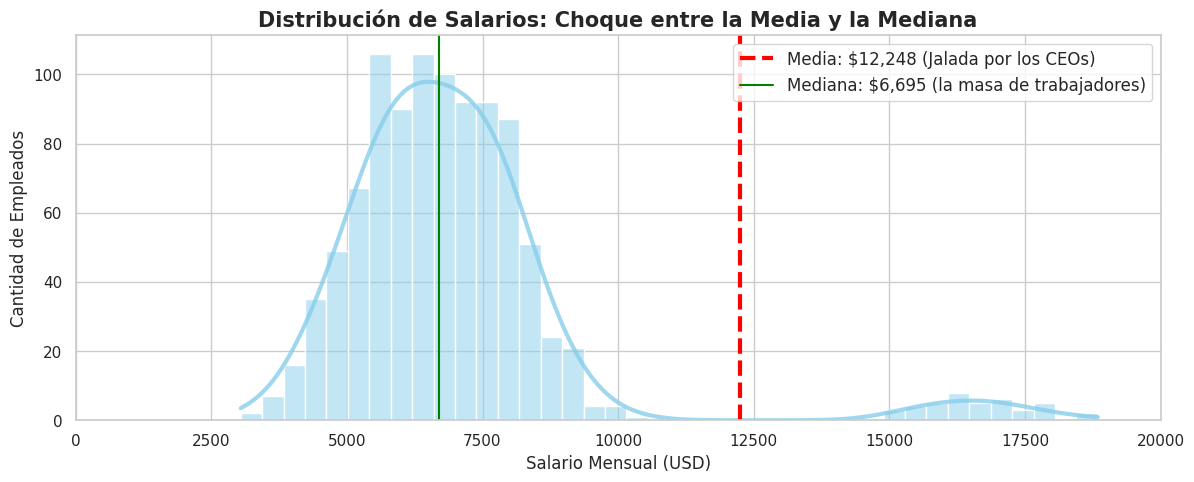

In [ ]:
#Hallar la mediana
mediana_salario = df_hr['Salario_USD'].median()
media_salario = df_hr['Salario_USD'].mean()
print(f'La mediana de Salario de la empresa es: ${mediana_salario:1f} dolares')

plt.figure(figsize=(14,5))
datos_visuales = df_hr[df_hr['Salario_USD'] < 35000]
sns.histplot(datos_visuales['Salario_USD'], bins=40, color='skyblue', kde=True,
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #Destacamos la envolvemnte en azul oscuro
#Aqui ponemos las lineas verticales de la media y la mediana.
plt.axvline(media_salario, color='red', linestyle = 'dashed', linewidth = 3, label=f'Media: ${media_salario:,.0f} (Jalada por los CEOs)')
plt.axvline(mediana_salario, color='green', linestyle = 'solid', label=f'Mediana: ${mediana_salario:,.0f} (la masa de trabajadores)' )

plt.title('Distribución de Salarios: Choque entre la Media y la Mediana', fontsize= 15, fontweight ='bold')
plt.xlabel('Salario Mensual (USD)')
plt.ylabel('Cantidad de Empleados')
plt.xlim(0,20000)
plt.legend(fontsize=12)
plt.show()

MEDIDAS DE TENDENCIA CENTRAL Y LA ANATOMIA DEL BOXPLOT

34.0


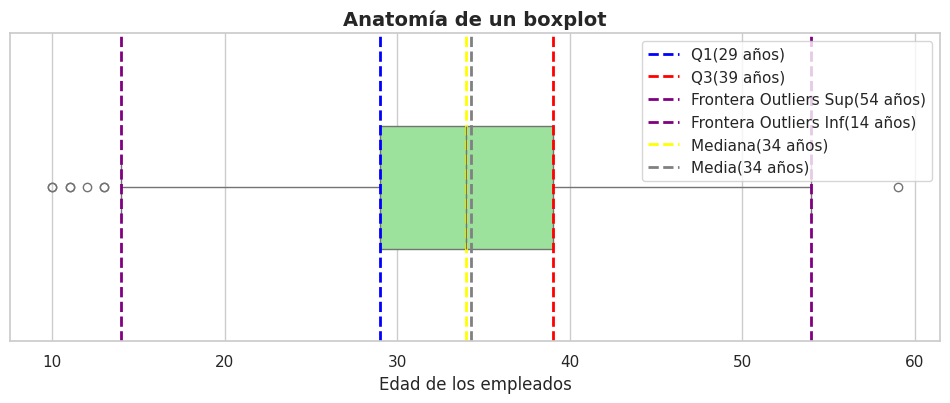

In [ ]:
Q1 = df_hr['Edad'].quantile(0.25) #Caluamos los cuartiles con la función quantile
mediana = df_hr['Edad'].median() #Calculamos la mediana
media = df_hr['Edad'].mean() #Calculamos la media
Q3 = df_hr['Edad'].quantile(0.75)
IQR = Q3 - Q1
lim_sup = Q3 + 1.5*IQR
lim_inf = Q1 - 1.5*IQR
print(mediana)
#grafica

plt.figure(figsize=(12,4)) #Definimos el tamaño del plot exterior
sns.boxplot(x=df_hr['Edad'], color='lightgreen', width=0.4) #Creamos el boxplot con seaborn

#trazos verticales

plt.axvline(Q1, color = 'blue', linestyle ='--', linewidth ='2', label=f'Q1({Q1:.0f} años)')
plt.axvline(Q3, color = 'red', linestyle ='--', linewidth ='2', label=f'Q3({Q3:.0f} años)')
plt.axvline(lim_sup, color = 'purple', linestyle ='--', linewidth ='2', label=f'Frontera Outliers Sup ({lim_sup:.0f} años)')
plt.axvline(lim_inf, color = 'purple', linestyle ='--', linewidth ='2', label=f'Frontera Outliers Inf ({lim_inf:.0f} años)')
plt.axvline(mediana, color = 'yellow', linestyle ='--', linewidth ='2', label=f'Mediana({mediana:.0f} años)')
plt.axvline(media, color = 'gray', linestyle ='--', linewidth ='2', label=f'Media({media:.0f} años)')

plt.title('Anatomía de un boxplot', fontsize=14, fontweight='bold')
plt.xlabel('Edad de los empleados')
plt.legend()
plt.show()

(0.0, 70.0)

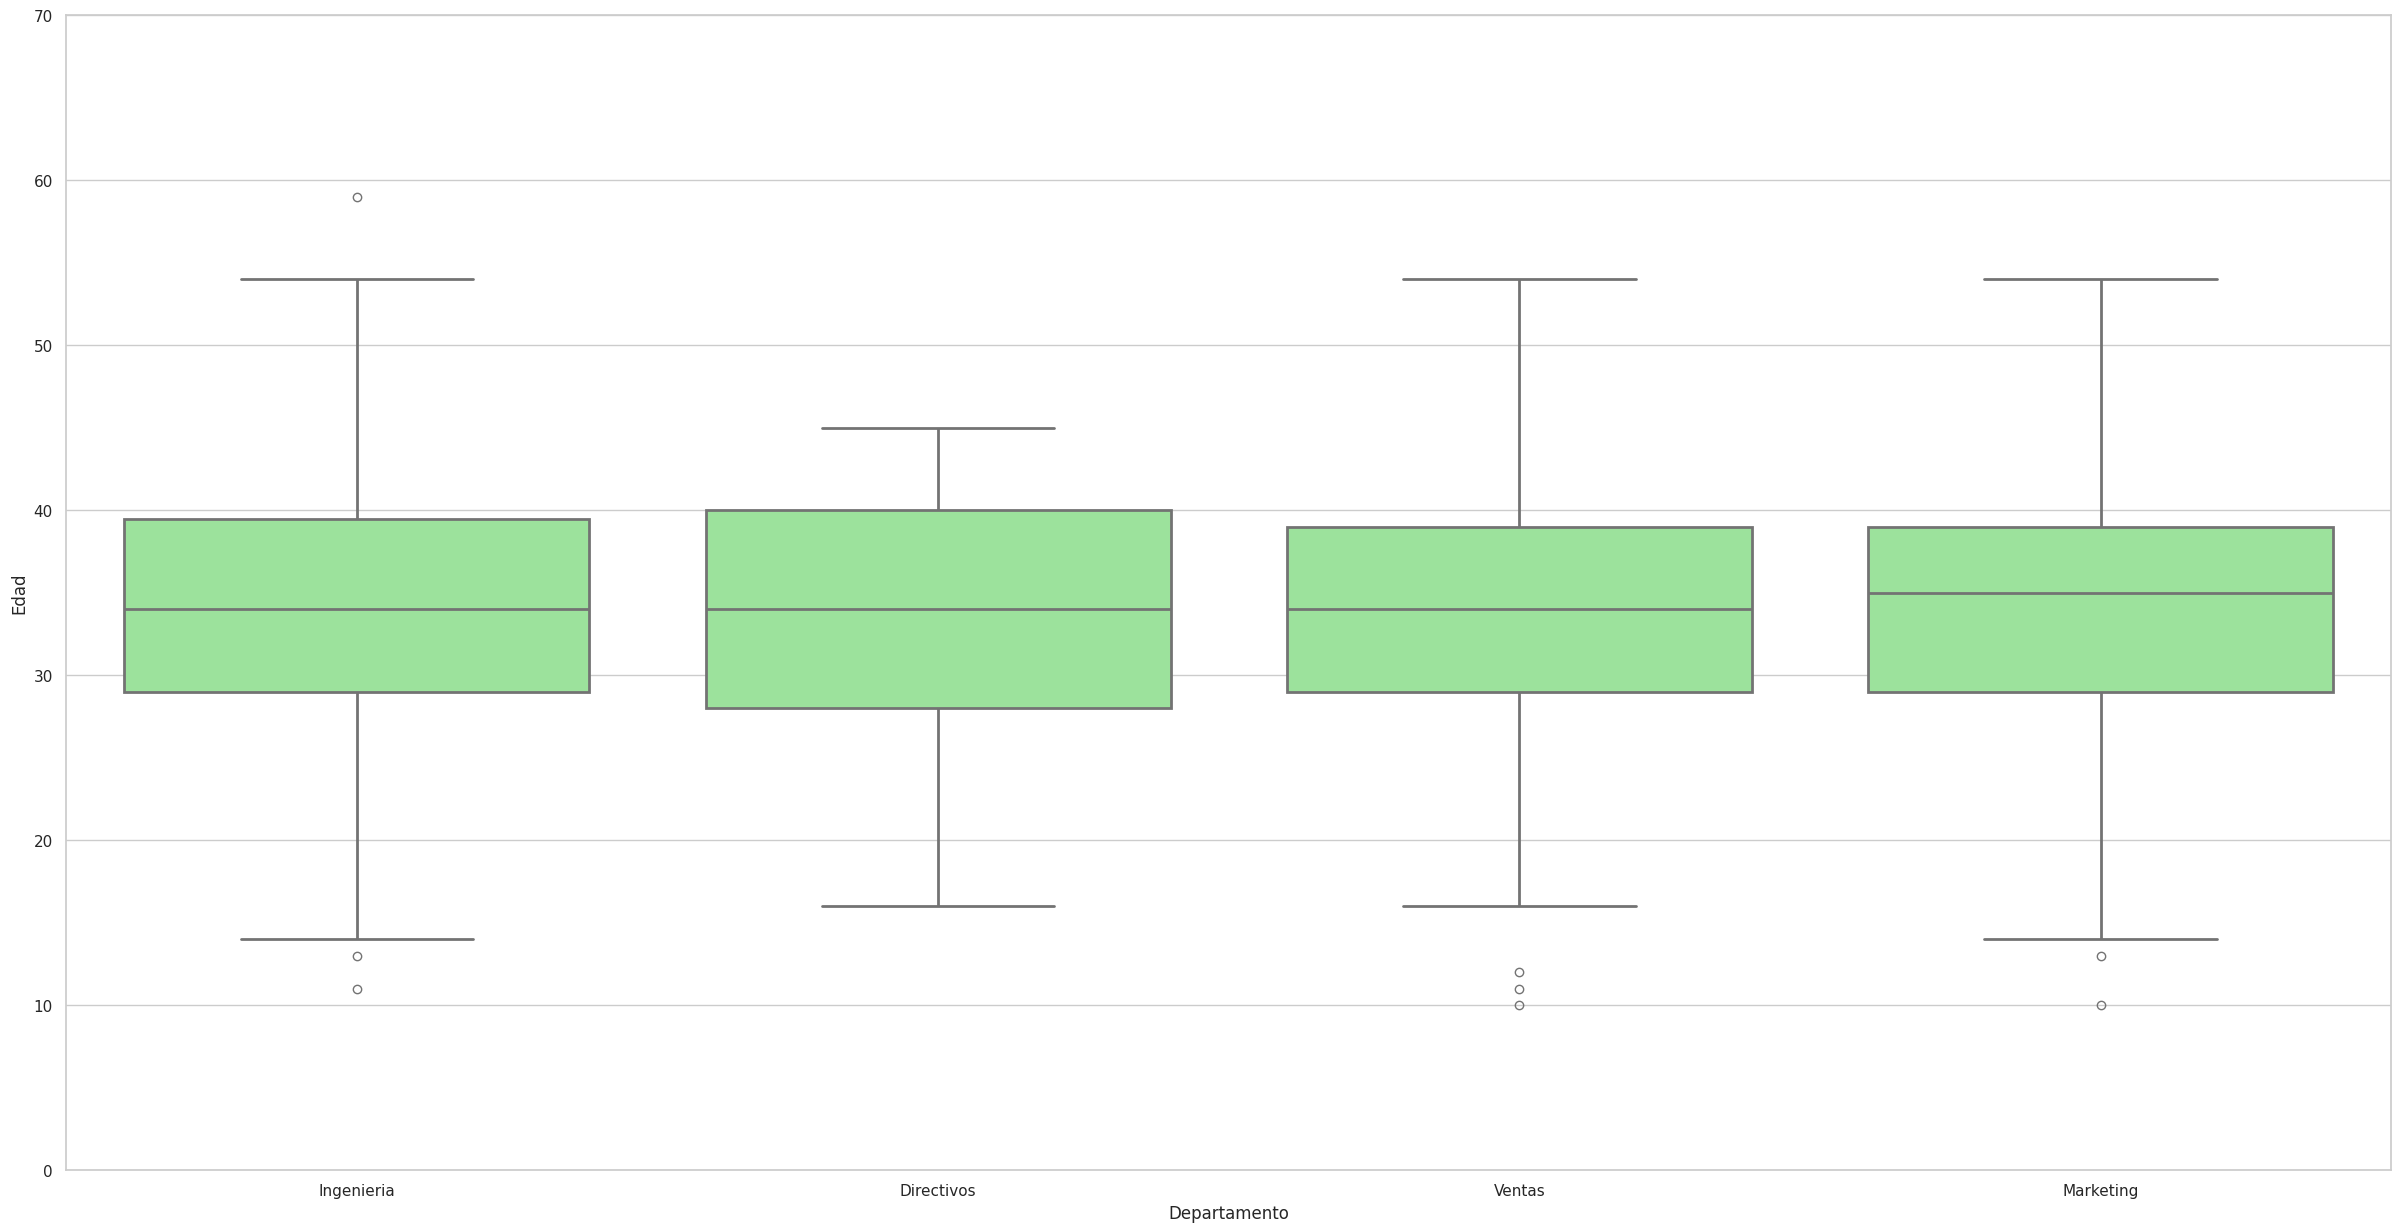

In [ ]:
#multiple boxplot

plt.figure(figsize=(30,15))
sns.boxplot(x="Departamento", y="Edad", data=df_hr, color='lightgreen', linewidth=2)
plt.ylim((0,70))


(0.0, 200000.0)

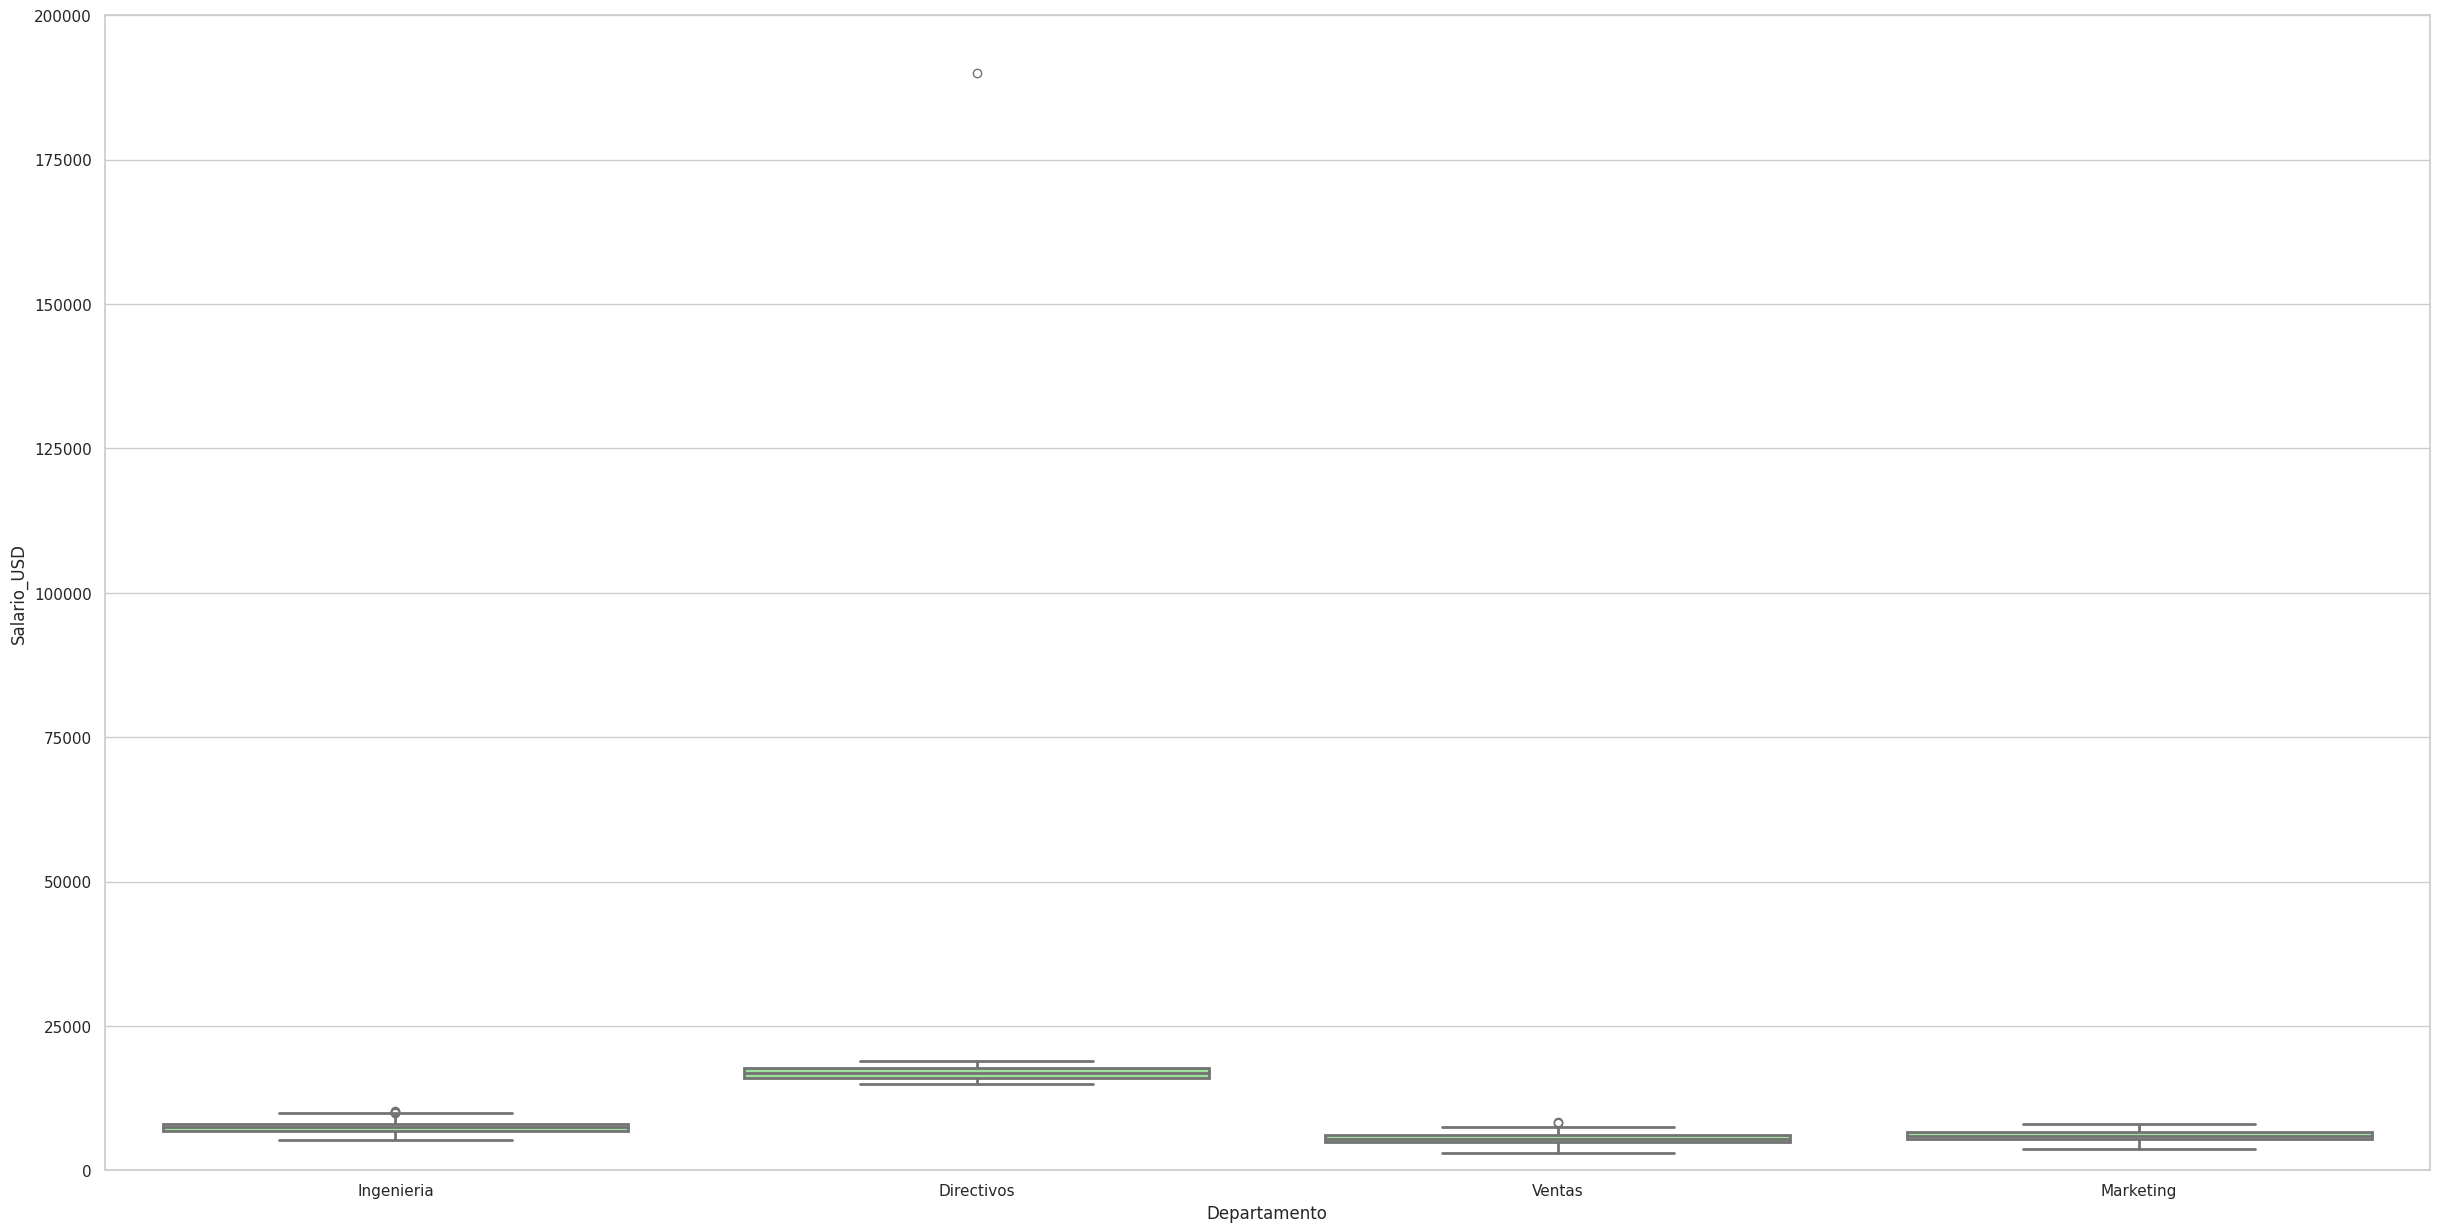

In [ ]:
#multiple boxplot 2

plt.figure(figsize=(30,15))
sns.boxplot(x="Departamento", y="Salario_USD", data=df_hr, color='lightgreen', linewidth=2)
plt.ylim((0,200000))

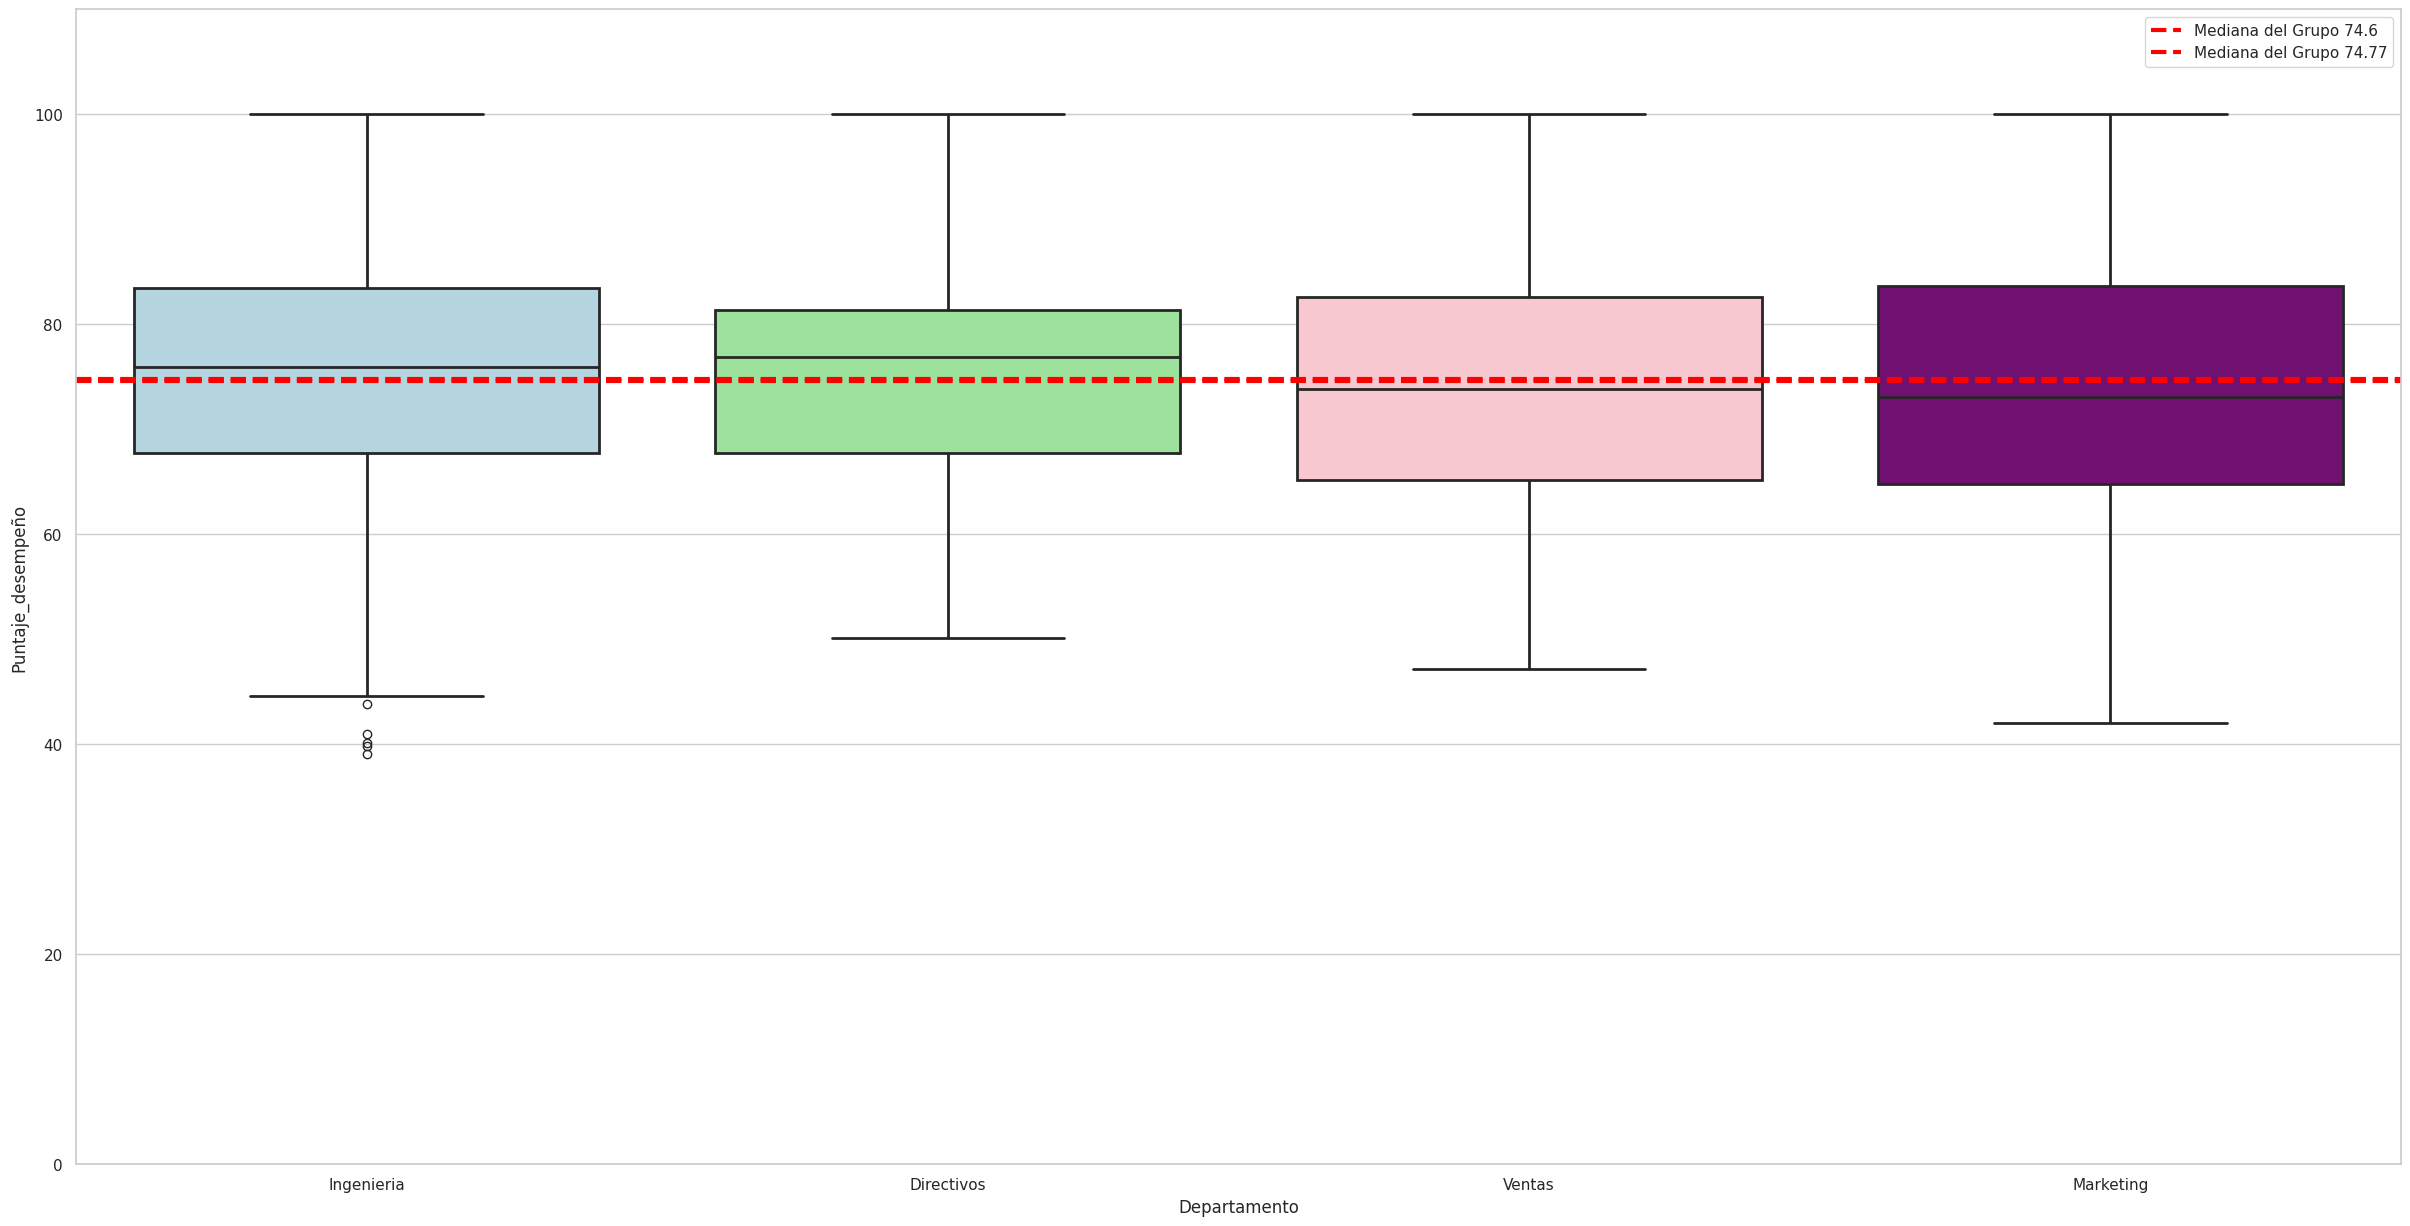

In [ ]:
#multiple boxplot 3

plt.figure(figsize=(30,15))
sns.boxplot(x="Departamento", y="Puntaje_desempeño", data=df_hr, hue = 'Departamento', palette=['lightblue', 'lightgreen', 'pink', 'purple'], linewidth=2)
plt.ylim((0,110))
median_group = df_hr['Puntaje_desempeño'].median()
mean_group = df_hr['Puntaje_desempeño'].mean()
plt.axhline(median_group, linewidth='3', linestyle='--', color='red',label=f'Mediana del Grupo {median_group}')
plt.axhline(mean_group, linewidth='3', linestyle='--', color='red',label=f'Mediana del Grupo {mean_group.round(2)}')
plt.legend()
plt.show()